<div style="border-bottom: 2px solid #e8a435; padding-bottom: 20px; margin-bottom: 30px;">
<div style="display: flex; align-items: center; gap: 16px;">
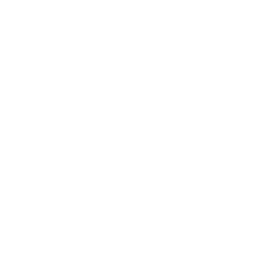
<div>
<h1 style="margin: 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; font-weight: 700; color: #1a1a2e; font-size: 28px; letter-spacing: -0.5px;">Ressourcenauslastung der Krankenhausabteilungen — horizontales Balkendiagramm</h1>
<p style="margin: 4px 0 0 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #6c6c8a; font-size: 14px;">Jenner Analytics Ltd &nbsp;|&nbsp; Gesundheitswesen / Krankenhausbetrieb &nbsp;|&nbsp; März 2026</p>
</div>
</div>
</div>

## Management-Zusammenfassung

Dieses Beispiel verwendet horizontale Balkendiagramme mit **PROC GCHART** (HBAR), um die Personalstunden über sechs klinische Abteilungen für Q1 2026 darzustellen. Ein synthetisches Personaleinsatzprotokoll mit **90 Schichtdatensätzen** (15 je Abteilung) liefert drei Ansichten: ein nach Gesamtstunden sortiertes Balkendiagramm, die mittlere Schichtlänge je Abteilung sowie gruppierte HBARs, die jede Abteilung nach Personalkategorie und nach Schicht aufteilen. `SUMVAR=` summiert die tatsächlichen Arbeitsstunden statt Datensätze zu zählen, `TYPE=SUM`/`TYPE=MEAN` schaltet zwischen den beiden Statistiken um, `DESCENDING` sortiert die Abteilungen absteigend, und `GROUP=` zeichnet für eine zweite Dimension nebeneinanderliegende gruppierte Balken.

Die Ausgabe unterstützt die quartalsweise Überprüfung der betrieblichen Effizienz: Sie zeigt, welche Abteilungen die meisten Arbeitsstunden verbrauchen, welche die längsten Schichten fahren, und wie sich das Tag-/Spät-/Nachtschicht-Muster zwischen durchgehend versorgten Akutstationen und tagesorientierten Diensten unterscheidet.

## Datenquellen

| Quelle | Beschreibung | Datensätze |
|--------|-------------|--------|
| WORK.STAFFING_LOG | Einzelne Schicht-Arbeitsstunden-Datensätze | 90 |
| WORK.DEPT_SUMMARY | Abteilungssummen und mittlere Schichtlänge | 6 |

---

In [1]:
/* --------------------------------------------------------
   Synthetisches Personaleinsatzprotokoll fuer ein Krankenhaus.
   Q1 2026: 6 klinische Abteilungen, 4 Personalkategorien,
   3 Schichten. Auf 15 Schichtdatensaetze je Abteilung
   (90 insgesamt) skaliert, damit das gesamte Abteilungsprofil
   sichtbar bleibt.
   -------------------------------------------------------- */
DATEN work.staffing_log;
    AUFRUFEN streaminit(20260601);
    LÄNGE department $24 resource_type $18 shift $14;

    /* Personalkategorie-Mix (pflegelastige klinische Besetzung) */
    FELD resw[4] _temporary_ (0.50 0.20 0.20 0.10);

    /* Basis-Schichtverteilung, verschoben Richtung Nacht fuer 24/7-Einheiten */
    FELD shfw[3] _temporary_ (0.45 0.30 0.25);
    FELD nightlift[6] _temporary_
        (0.18 0.00 0.22 -0.05 -0.05 0.05);

    AUSFÜHRUNG di = 1 BIS 6;
        WENN di = 1 DANN department = 'Notaufnahme';
        SONST WENN di = 2 DANN department = 'Chirurgie';
        SONST WENN di = 3 DANN department = 'Intensivstation';
        SONST WENN di = 4 DANN department = 'Pädiatrie';
        SONST WENN di = 5 DANN department = 'Onkologie';
        SONST department = 'Geburtshilfe';

        AUSFÜHRUNG rec = 1 BIS 15;

            /* Personalkategorie ueber gewichtete Ziehung */
            u = rand('uniform'); cum = 0;
            AUSFÜHRUNG r = 1 BIS 4;
                cum + resw[r];
                WENN u <= cum DANN AUSFÜHRUNG;
                    WENN r = 1 DANN resource_type = 'Pflege';
                    SONST WENN r = 2 DANN resource_type = 'Ärzteschaft';
                    SONST WENN r = 3 DANN resource_type = 'Fachpersonal';
                    SONST resource_type = 'Unterstützung';
                    VERLASSEN;
                ENDE;
            ENDE;

            /* Schicht ueber abteilungsspezifische Nacht-Verschiebung */
            w1 = shfw[1] - nightlift[di] / 2;
            w2 = shfw[2] - nightlift[di] / 2;
            u = rand('uniform');
            WENN u <= w1 DANN shift = 'Tagschicht';
            SONST WENN u <= w1 + w2 DANN shift = 'Spätschicht';
            SONST shift = 'Nachtschicht';

            /* Stunden: Aerzte und Chirurgie fahren laengere Schichten */
            BASE = 8;
            WENN resource_type = 'Ärzteschaft' DANN BASE = BASE + 1.5;
            WENN department = 'Chirurgie'      DANN BASE = BASE + 1.0;
            hours_worked = round(BASE + rand('normal', 0, 0.8), 0.25);
            WENN hours_worked < 4 DANN hours_worked = 4;

            AUSGABE;
        ENDE;
    ENDE;
    BEHALTEN department resource_type shift hours_worked;
AUSFÜHREN;


NOTE: DATA work.staffing_log


NOTE: Wrote work.staffing_log (90 rows, 4 columns).
NOTE: DATA elapsed:
  wall  0.03 seconds
  cpu   0.03 seconds


In [2]:
/* --------------------------------------------------------
   Abteilungssummen und mittlere Schichtlaenge,
   sortiert nach Gesamtarbeitsstunden.
   -------------------------------------------------------- */
PROZEDUR SQL;
    ERSTELLEN TABELLE work.dept_summary AS
    AUSWÄHLEN department,
           sum(hours_worked)  AS total_hours   format=8.2,
           count(*)           AS shift_count,
           mean(hours_worked) AS avg_shift_hrs  format=6.2
    VON work.staffing_log
    GROUP NACH department
    ORDER NACH total_hours DESC;
QUIT;

PROZEDUR DRUCKEN DATEN=work.dept_summary noobs BEZEICHNUNG;
    BEZEICHNUNG total_hours   = 'Gesamtstunden'
          shift_count   = 'Schichten'
          avg_shift_hrs = 'Mittlere Schicht (Std.)';
    TITEL 'Abteilungs-Arbeitszeitübersicht - Q1 2026';
AUSFÜHREN;
TITEL;

                                       Abteilungs-Arbeitszeitübersicht - Q1 2026                                        

     department  Gesamtstunden  Schichten  Mittlere Schicht (Std.)
Chirurgie               136.25         15                     9.08
Intensivstation         128.50         15                     8.57
Geburtshilfe            127.75         15                     8.52
Pädiatrie               124.75         15                     8.32
Onkologie               123.75         15                     8.25
Notaufnahme             119.25         15                     7.95




NOTE: PROC SQL 

NOTE: Table work.dept_summary created.
NOTE: PROC SQL statement used.
NOTE: PROC PRINT data=work.dept_summary

NOTE: PROC PRINT completed: 6 observations printed, 4 variables


---

                                             Arbeitsstunden nach Abteilung                                              

                                                  The MEANS Procedure

                                  Analysis Variable : hours_worked Geleistete Stunden

        department                 Sum           Mean          N Obs
        ------------------------------------------------------------
        Chirurgie               136.25           9.08             15
        Geburtshilfe            127.75           8.52             15
        Intensivstation         128.50           8.57             15
        Notaufnahme             119.25           7.95             15
        Onkologie               123.75           8.25             15
        Pädiatrie               124.75           8.32             15
        ------------------------------------------------------------

                                            Schichtverteilung nach Abteilung                      


NOTE: PROC MEANS
NOTE: PROC MEANS statement used.
NOTE: PROC FREQ
NOTE: ODS plot written: freq_mosaic_department_shift.spec.json
NOTE: PROC FREQ statement used.


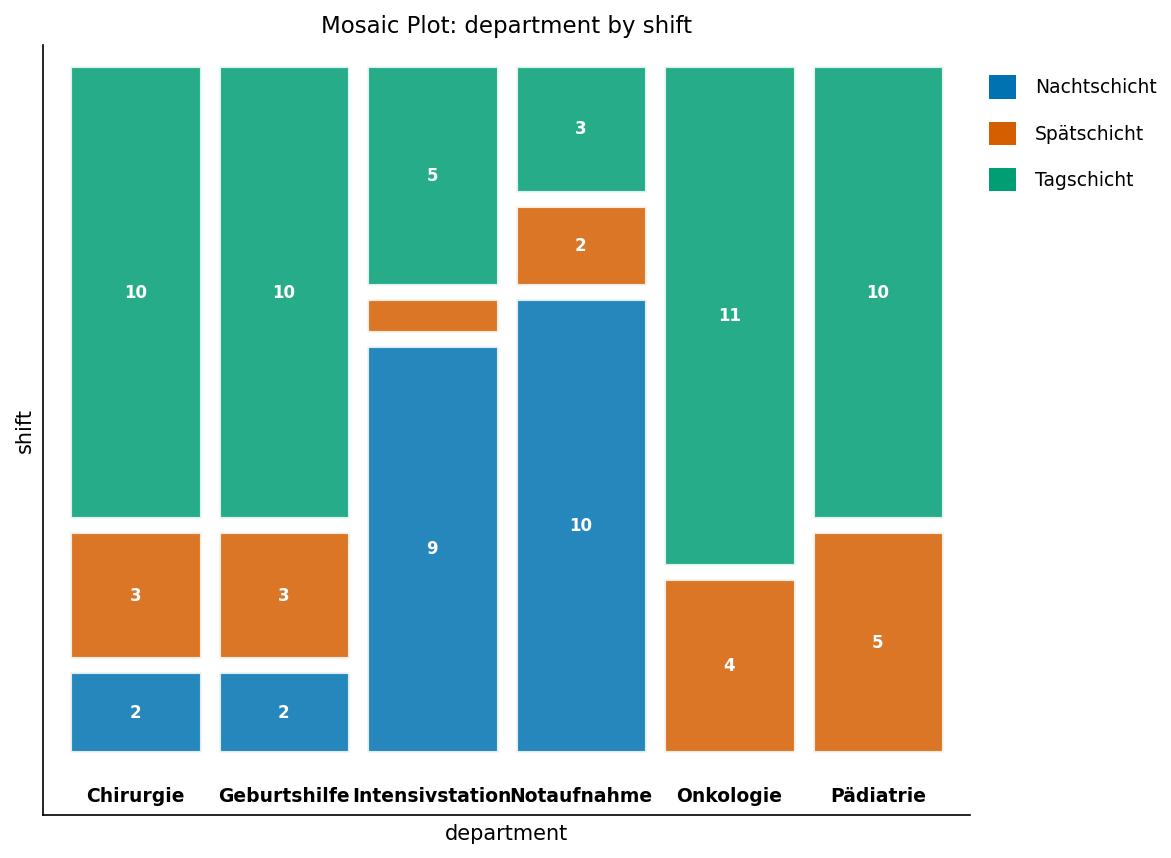

In [3]:
/* --------------------------------------------------------
   Basistabellen: Arbeitsstunden je Abteilung und die
   Tag-/Spät-/Nachtschicht-Verteilung je Abteilung.
   -------------------------------------------------------- */
PROZEDUR MITTELWERTE DATEN=work.staffing_log sum mean n maxdec=2;
    KLASSE department;
    VAR hours_worked;
    BEZEICHNUNG hours_worked = 'Geleistete Stunden';
    TITEL 'Arbeitsstunden nach Abteilung';
AUSFÜHREN;

PROZEDUR HÄUFIGKEITEN DATEN=work.staffing_log;
    TABLES department * shift / norow nocol nopercent;
    TITEL 'Schichtverteilung nach Abteilung';
AUSFÜHREN;
TITEL;

---


NOTE: PROC GCHART data=work.staffing_log

NOTE: ODS plot written: gchart_hbar.spec.json


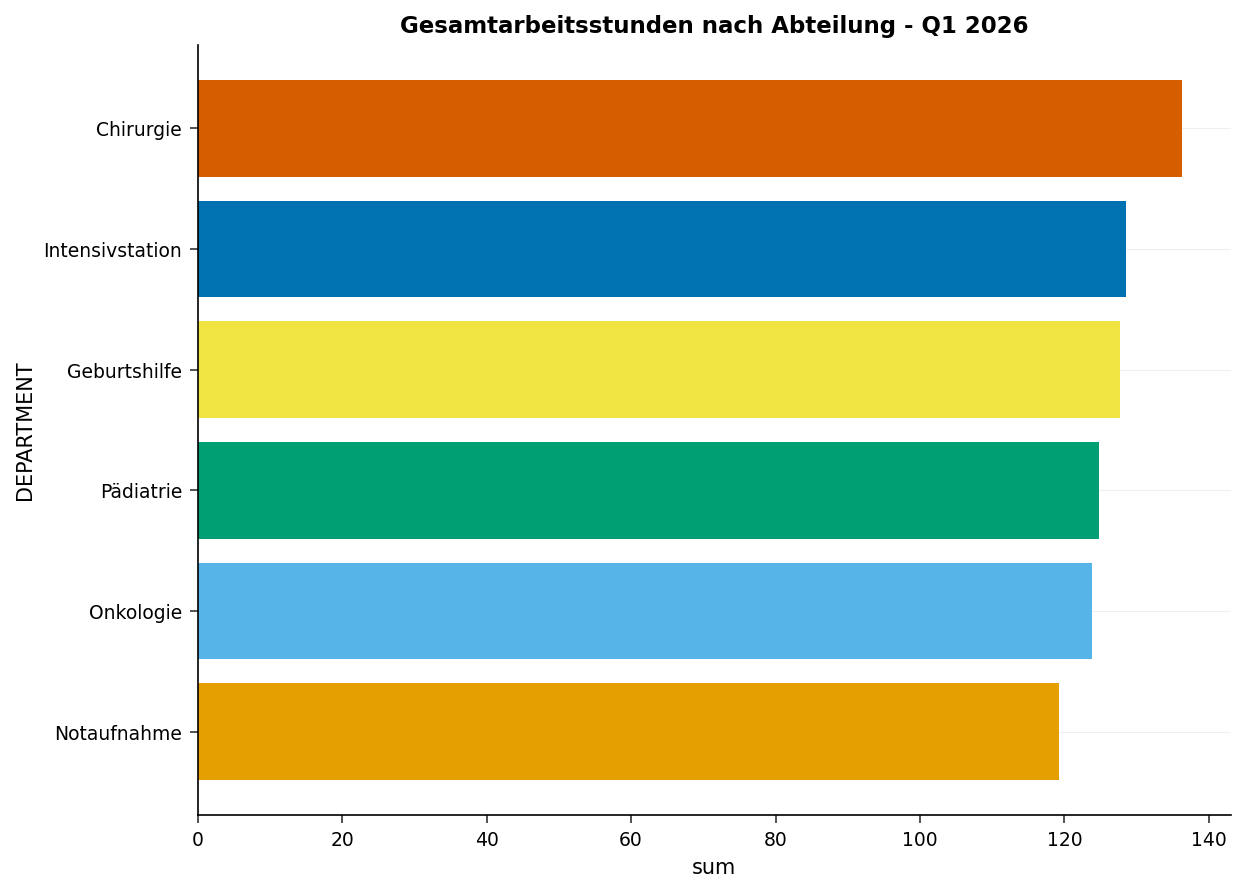

In [4]:
/* --------------------------------------------------------
   Uebersichts-HBAR: Gesamtarbeitsstunden je Abteilung.
   SUMVAR= summiert Stunden; DESCENDING sortiert absteigend.
   -------------------------------------------------------- */
PROZEDUR GCHART DATEN=work.staffing_log;
    HBAR department / SUMVAR=hours_worked
                      type=sum
                      ABSTEIGEND;
    TITEL 'Gesamtarbeitsstunden nach Abteilung - Q1 2026';
AUSFÜHREN;
QUIT;
TITEL;

### Aufteilung jeder Abteilung nach Personalkategorie

`GROUP=` zeichnet fuer jede Abteilung eine Gruppe nebeneinanderliegender horizontaler Balken, einen Balken je Personalkategorie. Da `SUMVAR=hours_worked` weiterhin gilt, misst jeder Balken summierte Arbeitsstunden statt einer Datensatzanzahl, sodass das Diagramm zeigt, wie sich Pflege-, Ärzte-, Fachpersonal- und Unterstützungsstunden *innerhalb* jeder Abteilung verhalten.

In [5]:
/* --------------------------------------------------------
   PATTERN-Anweisungen: abgestimmte 4-Farb-Palette,
   ein Muster je Personalkategorie-Untergruppe
   -------------------------------------------------------- */
pattern1 VALUE=solid color=cx2C5F8A;   /* Pflege — dunkelblau        */
pattern2 VALUE=solid color=cx28A745;   /* Ärzteschaft — grün          */
pattern3 VALUE=solid color=cxE8650A;   /* Fachpersonal — bernsteinfarben */
pattern4 VALUE=solid color=cx6C757D;   /* Unterstützung — grau       */

                                    Abteilungsarbeitsstunden nach Personalkategorie                                     


Quelle: Personalmanagementsystem | Berichtszeitraum: Jan-Mär 2026



NOTE: Option TITLE changed to Abteilungsarbeitsstunden nach Personalkategorie.
NOTE: Option FOOTNOTE changed to Quelle: Personalmanagementsystem | Berichtszeitraum: Jan-Mär 2026.
NOTE: PROC GCHART data=work.staffing_log

NOTE: ODS plot written: gchart_hbar.spec.json


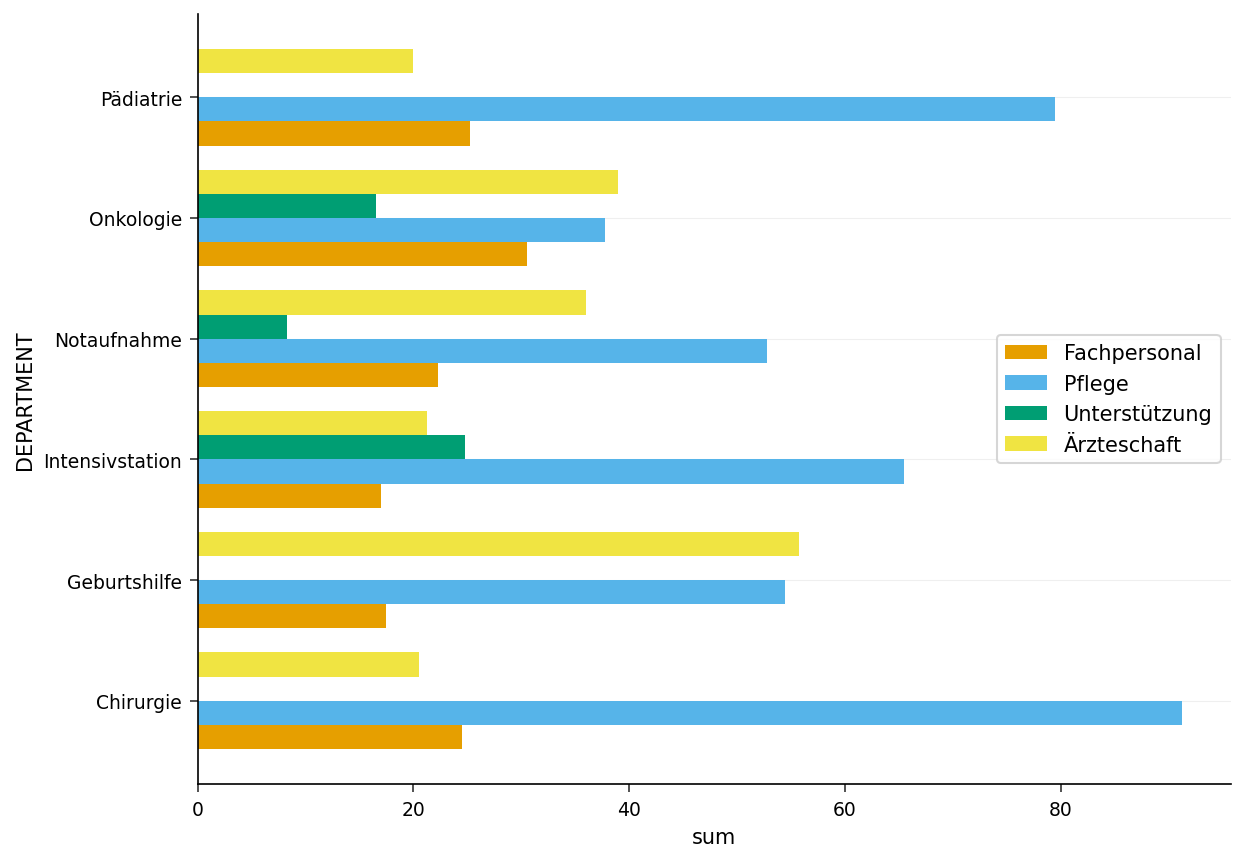

In [6]:
/* --------------------------------------------------------
   HBAR gruppiert nach Personalkategorie (GROUP=).
   Jede Abteilung wird zu einer Gruppe von Balken -- einer
   je Personalkategorie -- gemessen in summierten Arbeitsstunden.
   -------------------------------------------------------- */
TITEL 'Abteilungsarbeitsstunden nach Personalkategorie';
footnote JUSTIFY=LEFT
    'Quelle: Personalmanagementsystem | Berichtszeitraum: Jan-Mär 2026';

PROZEDUR GCHART DATEN=work.staffing_log;
    HBAR department / GROUP=resource_type
                      SUMVAR=hours_worked
                      type=sum;
AUSFÜHREN;
QUIT;

TITEL; footnote;

                                         Abteilungsarbeitsstunden nach Schicht                                          


Gruppierte Balken trennen die Anteile aus Tag-, Spät- und Nachtschicht je Abteilung



NOTE: Option TITLE changed to Abteilungsarbeitsstunden nach Schicht.
NOTE: Option FOOTNOTE changed to Gruppierte Balken trennen die Anteile aus Tag-, Spät- und Nachtschicht je Abteilung.
NOTE: PROC GCHART data=work.staffing_log

NOTE: ODS plot written: gchart_hbar.spec.json


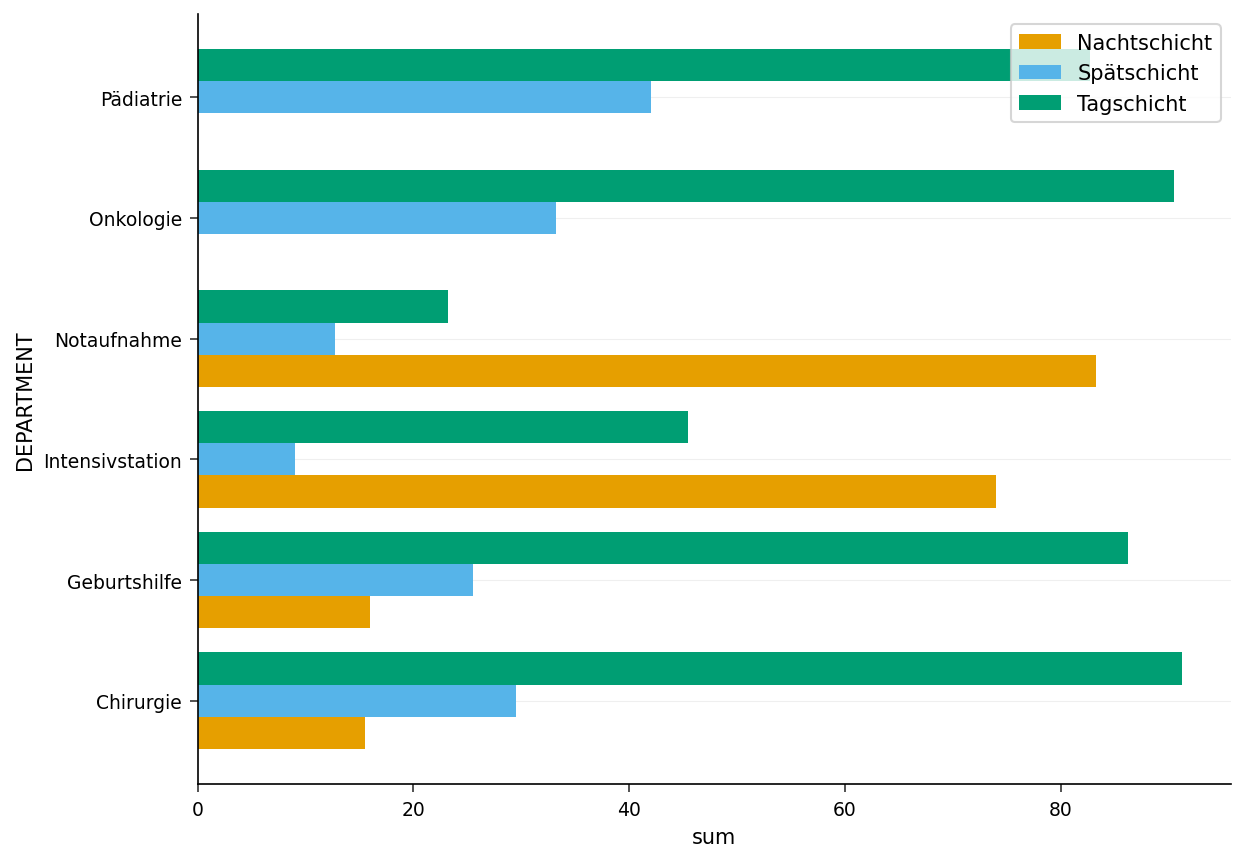

In [7]:
/* --------------------------------------------------------
   HBAR gruppiert nach Schicht (GROUP=).
   Trennt Tag-/Spät-/Nachtschicht-Stunden innerhalb jeder
   Abteilung -- hebt die 24/7-Akutstationen hervor.
   -------------------------------------------------------- */
TITEL 'Abteilungsarbeitsstunden nach Schicht';
footnote JUSTIFY=LEFT
    'Gruppierte Balken trennen die Anteile aus Tag-, Spät- und Nachtschicht je Abteilung';

PROZEDUR GCHART DATEN=work.staffing_log;
    HBAR department / GROUP=shift
                      SUMVAR=hours_worked
                      type=sum;
AUSFÜHREN;
QUIT;

TITEL; footnote;


NOTE: PROC GCHART data=work.staffing_log

NOTE: ODS plot written: gchart_hbar.spec.json


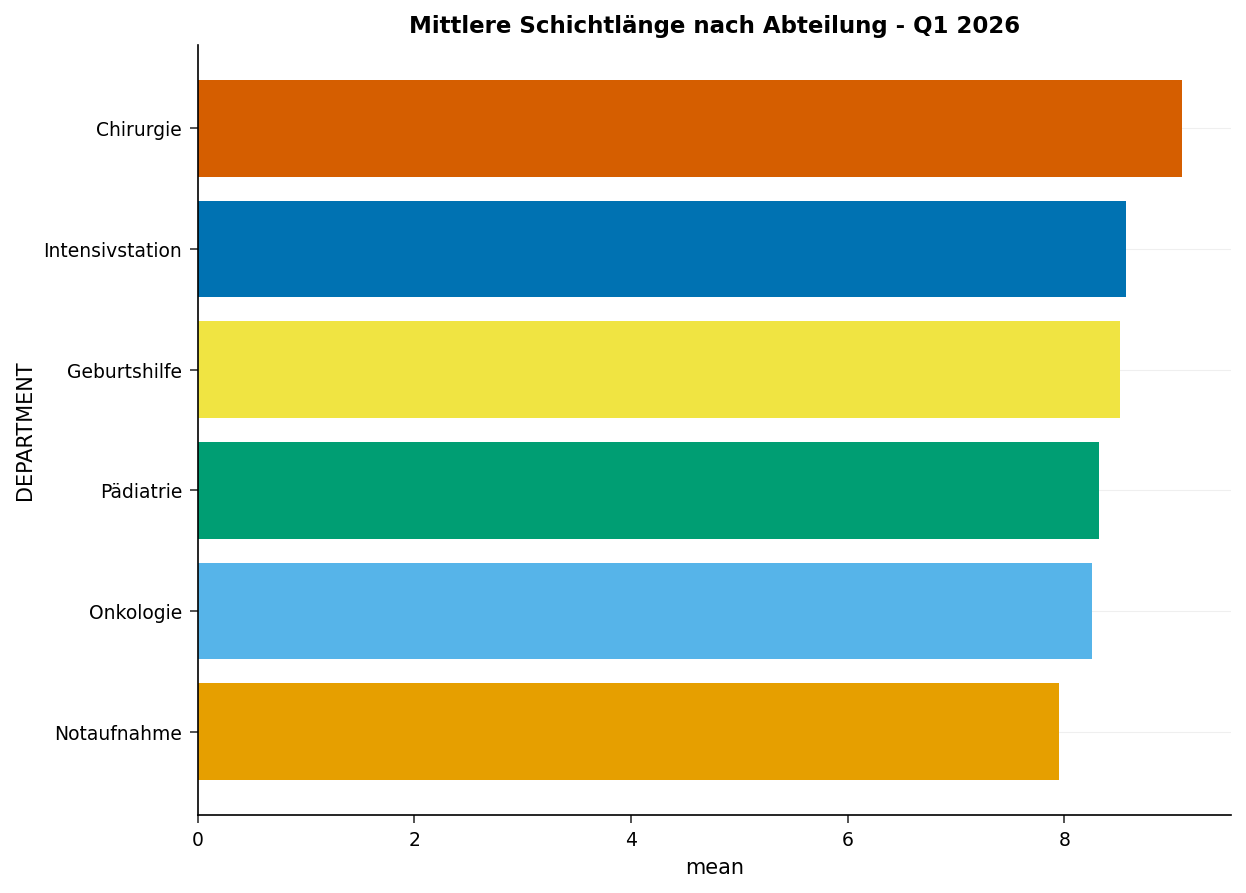

In [8]:
/* --------------------------------------------------------
   Mittlere Schichtlaenge je Abteilung (TYPE=MEAN).
   Zeigt, ob eine Abteilung lange Schichten oder viele
   kuerzere faehrt, unabhaengig vom Gesamtvolumen.
   -------------------------------------------------------- */
PROZEDUR GCHART DATEN=work.staffing_log;
    HBAR department / SUMVAR=hours_worked
                      type=mean
                      ABSTEIGEND;
    TITEL 'Mittlere Schichtlänge nach Abteilung - Q1 2026';
AUSFÜHREN;
QUIT;
TITEL;

---

### Interpretation

Über die 90 Schichtdatensätze hinweg bewegen sich die Gesamtarbeitsstunden in einer engen Bandbreite von **119,25** (Notaufnahme) bis **136,25** (Chirurgie), weil jede Abteilung in diesem Zeitraum dieselben 15 Schichten trägt — die Rangfolge spiegelt also **die Schichtlänge**, nicht die Schichtanzahl. Die Chirurgie führt sowohl das Gesamtstunden- als auch das Mittelwert-Diagramm an mit **9,08 Stunden** je Schicht, was zu längeren Operationsfällen und der ärztelastigen Besetzung passt, die solche Fälle erfordern. Die Notaufnahme liegt bei den Stunden am unteren Ende (Mittelwert **7,95**), obwohl sie eine der am stärksten frequentierten Einheiten ist, weil ihre Arbeit in kürzeren Schichten mit höherer Fluktuation geleistet wird.

Das nach Schicht gruppierte HBAR und das Mosaik-Panel erzählen die betrieblich wichtige Geschichte. **Notaufnahme und Intensivstation sind nachtdominant** — 10 von 15 bzw. 9 von 15 Schichten fallen jeweils auf die Nachtschicht —, während **Onkologie und Pädiatrie überhaupt keine Nachtschichten** verzeichnen und sich auf die Tagschicht konzentrieren (11 bzw. 10 Tagschichten). Das entspricht der Realität von Krankenhauspersonaleinsätzen: durchgehend versorgte Akutstationen laufen rund um die Uhr, während die onkologische Infusionstherapie und die allgemeine Pädiatrie tagesorientierte Dienste sind. Das Personalkategorie-Panel bestätigt in jeder Abteilung einen **pflegegeführten Mix**, wobei Ärzte- und Fachpersonalstunden die zweitwichtigsten Stufen bilden.

Für die Q2-Personalplanung ist die Konzentration der Nachtschichten in Notaufnahme und Intensivstation der Posten, den es zu beobachten gilt: Dort fallen Zuschlags- und Ermüdungsmanagementkosten an, und dort hat jede Änderung am Dienstplan die größte Budgetwirkung.

---

In [9]:
/* --------------------------------------------------------
   Export der Abteilungsübersicht fuer das
   Personalplanungssystem.
   -------------------------------------------------------- */
PROZEDUR EXPORT DATEN=work.dept_summary
    OUTFILE='q1_dept_labor_summary.csv'
    DBMS=csv REPLACE;
AUSFÜHREN;


NOTE: PROC EXPORT data=work.dept_summary outfile=q1_dept_labor_summary.csv

NOTE: Exported 6 rows to q1_dept_labor_summary.csv.


---
<div style="border-top: 1px solid #e0e0e0; padding-top: 16px; margin-top: 20px; display: flex; justify-content: space-between; align-items: center;">
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
&copy; 2026 Jenner Analytics Ltd &nbsp;&bull;&nbsp; Vertraulich
</div>
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
Bereitgestellt von <a href="https://docs.jenneranalytics.com" style="color: #e8a435; text-decoration: none;">Jenner</a>
</div>
</div>